<a href="https://colab.research.google.com/github/AdityaDhiman05/UPI-Analytics-Dashboard/blob/main/DAY_11_CAPSTONE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Install ipywidgets for interactivity
!pip install ipywidgets plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from ipywidgets import interact, widgets

# Set plot style
sns.set(style="whitegrid")



In [12]:
# Upload files if not already in Colab
from google.colab import files

uploaded = files.upload()
uploaded = files.upload()  # Upload 'upi_train_prepared.csv', 'upi_test_prepared.csv', 'best_random_forest_model.pkl'

# Load datasets
train_df = pd.read_csv("upi_train_prepared.csv")
test_df = pd.read_csv("upi_test_prepared.csv")

# Load model
best_model = joblib.load("best_random_forest_model.pkl")

# Feature & target
X_test = test_df[["Banks_Live_Scaled"]]
y_test = test_df["Volume_Mn"]

# Preview
train_df.head()


Saving upi_test_prepared.csv to upi_test_prepared (3).csv
Saving upi_train_prepared.csv to upi_train_prepared (3).csv


Saving best_random_forest_model.pkl to best_random_forest_model (1).pkl


,Banks_Live_Scaled,Volume_Mn
0,-0.711086,524.94
1,-0.013329,4186.48
2,1.903115,18395.01
3,1.836206,18301.51
4,-0.911811,171.40


In [13]:
total_volume = train_df["Volume_Mn"].sum()
avg_volume = train_df["Volume_Mn"].mean()
total_banks = train_df["Banks_Live_Scaled"].max()  # Scaled value; or replace with actual count if available

print(f"Total UPI Volume (Mn): {total_volume:.2f}")
print(f"Average Monthly Volume (Mn): {avg_volume:.2f}")
print(f"Number of Banks Live (Scaled): {total_banks:.2f}")


Total UPI Volume (Mn): 471120.61
Average Monthly Volume (Mn): 5234.67
Number of Banks Live (Scaled): 1.97


In [16]:
total_volume = train_df["Volume_Mn"].sum()
avg_volume = train_df["Volume_Mn"].mean()
max_volume = train_df["Volume_Mn"].max()
min_volume = train_df["Volume_Mn"].min()
total_banks = train_df["Banks_Live_Scaled"].max()

print(f"Total UPI Volume (Mn): {total_volume:.2f}")
print(f"Average Volume (Mn): {avg_volume:.2f}")
print(f"Max Volume (Mn): {max_volume:.2f}")
print(f"Min Volume (Mn): {min_volume:.2f}")
print(f"Banks Live (Scaled): {total_banks:.2f}")



Total UPI Volume (Mn): 471120.61
Average Volume (Mn): 5234.67
Max Volume (Mn): 20008.31
Min Volume (Mn): 0.00
Banks Live (Scaled): 1.97


In [19]:
# Only one feature in your dataset: Banks_Live_Scaled
X = train_df[["Banks_Live_Scaled"]]
y = train_df["Volume_Mn"]

y_pred = best_model.predict(X)

fig = px.scatter(x=y, y=y_pred, labels={"x":"Actual Volume (Mn)", "y":"Predicted Volume (Mn)"},
                 title="Predicted vs Actual UPI Transaction Volume")
fig.add_shape(type="line", x0=y.min(), y0=y.min(), x1=y.max(), y1=y.max(),
              line=dict(color="black", dash="dash"))
fig.show()


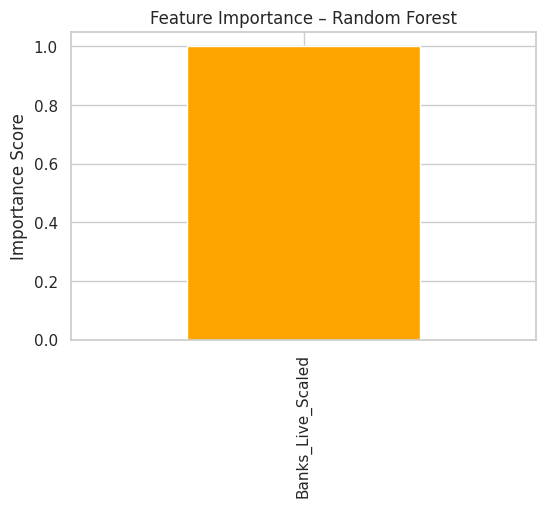

In [20]:
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', color='orange', figsize=(6,4))
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importance Score")
plt.show()
